In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

K NEAREST NEIGHBORS
Tamaño X_train: (1279, 11)
Tamaño X_test: (320, 11)
Tamaño y_train: (1279,)
Tamaño y_test: (320,)
classes: [3 4 5 6 7 8]
class_weights: {np.int64(3): np.float64(26.65), np.int64(4): np.float64(5.028301886792453), np.int64(5): np.float64(0.39133627019089573), np.int64(6): np.float64(0.4177115987460815), np.int64(7): np.float64(1.3391959798994975), np.int64(8): np.float64(14.805555555555555)}
Mejor k: 12 con accuracy de validación cruzada: 0.6669

Reporte de clasificación:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.73      0.70      0.71       136
           6       0.60      0.72      0.65       128
           7       0.62      0.53      0.57        40
           8       0.50      0.33      0.40         3

    accuracy                           0.65       320
   macro avg       0.41      0.38      0.39       320
weighted avg   

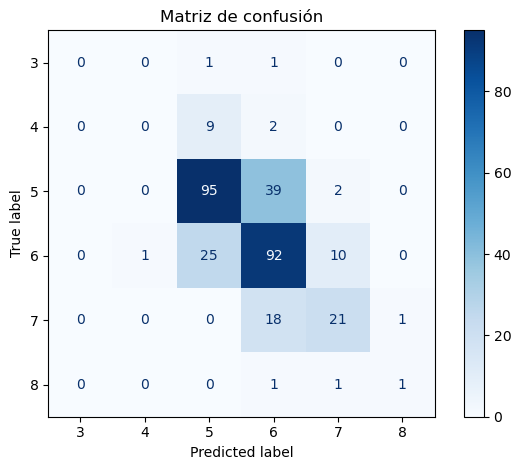

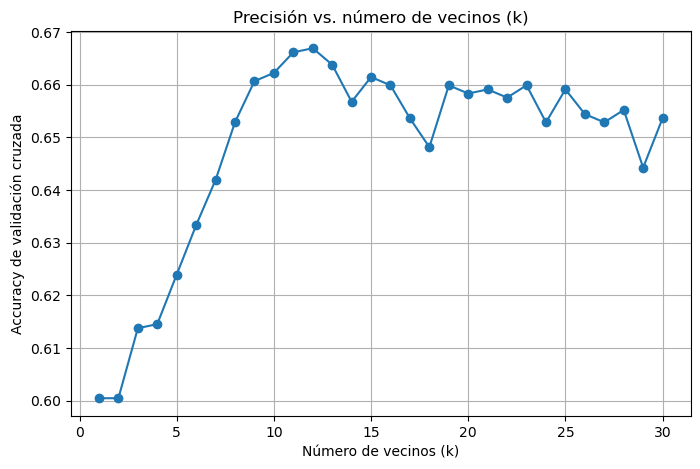

In [2]:

def K_Nearest_Neighbors(X_train, X_test, y_train, y_test, classes, class_weights, k_grid=range(1, 31), cv=5, weights='distance', metric='minkowski', p=2):
    print("K NEAREST NEIGHBORS")
    print("Tamaño X_train:", X_train.shape)
    print("Tamaño X_test:", X_test.shape)
    print("Tamaño y_train:", y_train.shape)
    print("Tamaño y_test:", y_test.shape)
    print("classes:", classes)
    print("class_weights:", class_weights)

    # Escalado
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Buscar el mejor k
    cv_scores = []
    for k in k_grid:
        knn_k = KNeighborsClassifier(n_neighbors=k, weights=weights, metric=metric, p=p)
        score = cross_val_score(knn_k, X_train_s, y_train, cv=cv, scoring='accuracy').mean()
        cv_scores.append(score)
    best_idx = int(np.argmax(cv_scores))
    best_k = list(k_grid)[best_idx]
    best_cv = cv_scores[best_idx]
    print(f"Mejor k: {best_k} con accuracy de validación cruzada: {best_cv:.4f}")

    # Entrenamiento final
    knn = KNeighborsClassifier(n_neighbors=best_k, weights=weights, metric=metric, p=p)
    knn.fit(X_train_s, y_train)

    # Evaluación
    y_pred = knn.predict(X_test_s)
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    print("Matriz de confusión (filas=verdadero, columnas=predicho, etiquetas en orden de 'classes'):\n", cm)

    # Matriz de confusión
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Matriz de confusión")
    plt.tight_layout()
    plt.show()
    
    # k v/s accuracy
    plt.figure(figsize=(8,5))
    plt.plot(list(k_grid), cv_scores, marker="o")
    plt.xlabel("Número de vecinos (k)")
    plt.ylabel("Accuracy de validación cruzada")
    plt.title("Precisión vs. número de vecinos (k)")
    plt.grid(True)
    plt.show()



    return {
        "scaler": scaler,
        "model": knn,
        "best_k": best_k,
        "best_cv": best_cv,
        "cv_scores": cv_scores,
        "classes": classes,
        "confusion_matrix": cm,
        "y_pred": y_pred
    }

# 1) Cargar los datos
df = pd.read_csv('dataset/winequality-red.csv')

# 2) Separar X e y
X = df.drop('quality', axis=1)
y = df['quality']

# 3) División en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# calcular pesos de las clases
classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weights = dict(zip(classes, class_weights))

# 4) Llamar a la función final
artifacts = K_Nearest_Neighbors(
    X_train, X_test, y_train, y_test,
    classes=classes,
    class_weights=class_weights,
    k_grid=range(1, 31),   # probar k=1..30
    cv=5,
    weights='distance'     
)


K NEAREST NEIGHBORS
Tamaño X_train: (1279, 11)
Tamaño X_test: (320, 11)
Tamaño y_train: (1279,)
Tamaño y_test: (320,)
classes: [4 5 6 7]
class_weights: {np.int64(4): np.float64(6.345238095238095), np.int64(5): np.float64(0.5870044052863436), np.int64(6): np.float64(0.6265673981191222), np.int64(7): np.float64(1.8421658986175116)}
Mejor k: 27 con accuracy de validación cruzada: 0.6873

Reporte de clasificación:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00        13
           5       0.69      0.72      0.71       136
           6       0.61      0.65      0.63       128
           7       0.68      0.65      0.67        43

    accuracy                           0.65       320
   macro avg       0.49      0.51      0.50       320
weighted avg       0.63      0.65      0.64       320

Matriz de confusión (filas=verdadero, columnas=predicho, etiquetas en orden de 'classes'):
 [[ 0 11  2  0]
 [ 0 98 37  1]
 [ 0 33 83 12]
 [ 0  0 15 28

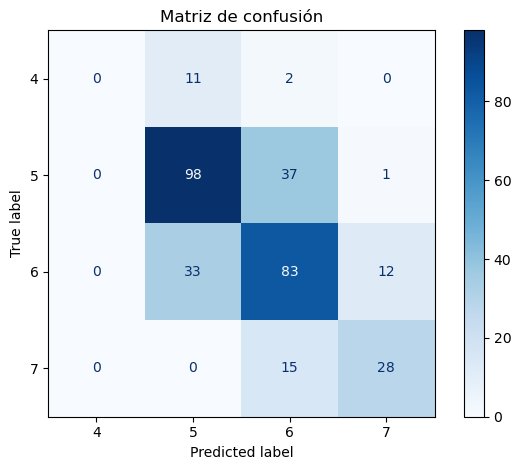

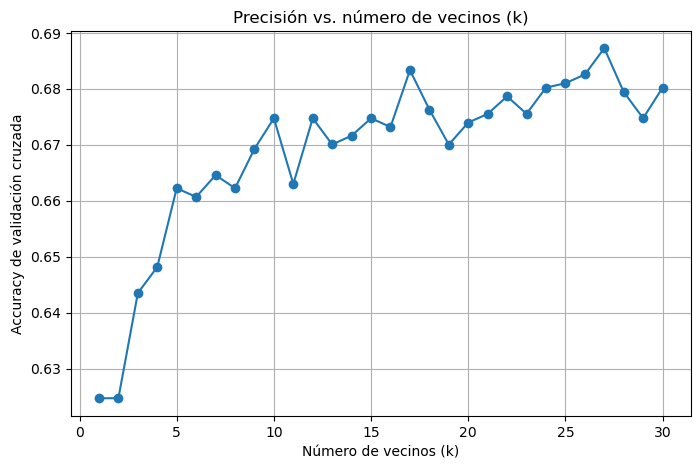

In [3]:
y = y.map({3:4, 4:4, 5:5, 6:6, 7:7, 8:7})

# 3) División en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# calcular pesos de las clases
classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weights = dict(zip(classes, class_weights))

# 4) Llamar a la función final
artifacts = K_Nearest_Neighbors(
    X_train, X_test, y_train, y_test,
    classes=classes,
    class_weights=class_weights,
    k_grid=range(1, 31),   # probar k=1..30
    cv=5,
    weights='distance'     
)

¿Seguirá subiendo el Accuracy con más vecinos?

K NEAREST NEIGHBORS
Tamaño X_train: (1279, 11)
Tamaño X_test: (320, 11)
Tamaño y_train: (1279,)
Tamaño y_test: (320,)
classes: [4 5 6 7]
class_weights: {np.int64(4): np.float64(6.345238095238095), np.int64(5): np.float64(0.5870044052863436), np.int64(6): np.float64(0.6265673981191222), np.int64(7): np.float64(1.8421658986175116)}
Mejor k: 27 con accuracy de validación cruzada: 0.6873

Reporte de clasificación:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00        13
           5       0.69      0.72      0.71       136
           6       0.61      0.65      0.63       128
           7       0.68      0.65      0.67        43

    accuracy                           0.65       320
   macro avg       0.49      0.51      0.50       320
weighted avg       0.63      0.65      0.64       320

Matriz de confusión (filas=verdadero, columnas=predicho, etiquetas en orden de 'classes'):
 [[ 0 11  2  0]
 [ 0 98 37  1]
 [ 0 33 83 12]
 [ 0  0 15 28

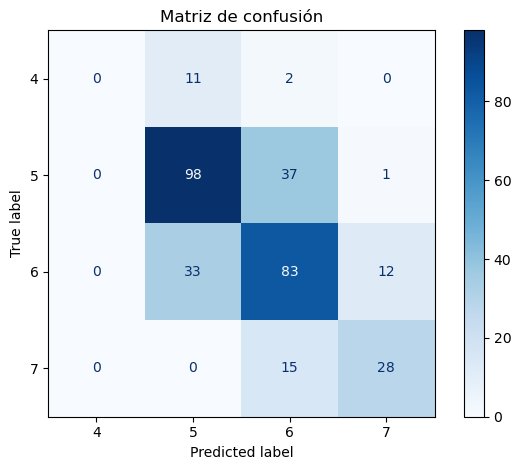

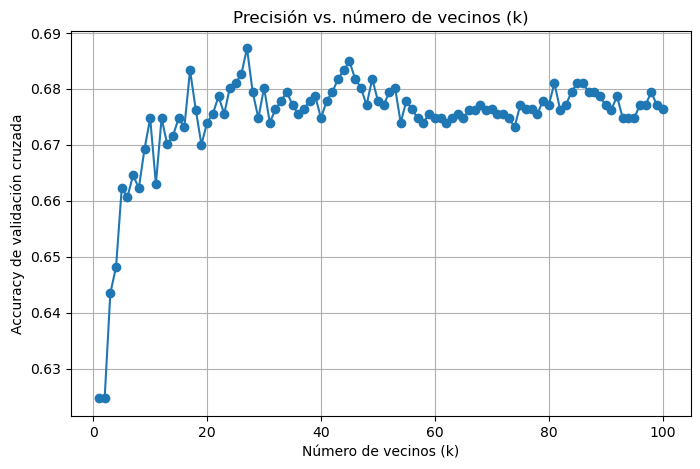

In [4]:
artifacts = K_Nearest_Neighbors(
    X_train, X_test, y_train, y_test,
    classes=classes,
    class_weights=class_weights,
    k_grid=range(1, 101),   # probar k=1..100
    cv=5,
    weights='distance'     
)


No, lástima.